# Klasyfikacja komórek krwi obwodowej za pomocą CNN
**Datasety:**
- Blood Cells Image Dataset (PBC) — Acevedo et al., 2022 (updated :))  
- Kouzehkanan et al., 2022, Scientific Reports

**Cel:** Klasyfikacja obrazów mikroskopowych do 8 klas komórek  

**Środowisko:** Google Colab + GPU (T4)  

**Klasy:** neutrofile, eozynofile, bazofile, limfocyty, monocyty, niedojrzałe granulocyty, erytroblasty, płytki krwi

---
## Pobieranie danych z Kaggle https://www.kaggle.com/datasets/unclesamulus/blood-cells-image-dataset (Trenowanie modelu)

In [2]:
# Instalacja kagglehub
!pip install kagglehub -q

import kagglehub

# Pobieranie datasetu
DATA_DIR = kagglehub.dataset_download("unclesamulus/blood-cells-image-dataset")
print(f"Dataset jest pod: {DATA_DIR}")

100%|██████████| 268M/268M [00:01<00:00, 164MB/s]

Extracting files...


Dataset jest pod: /root/.cache/kagglehub/datasets/unclesamulus/blood-cells-image-dataset/versions/2


In [3]:
import os

# Klasy i liczby obrazów
CLASSES_DIR = f"{DATA_DIR}/bloodcells_dataset"

for class_name in sorted(os.listdir(CLASSES_DIR)):
    class_path = os.path.join(CLASSES_DIR, class_name)
    n = len(os.listdir(class_path))
    print(f'{class_name}: {n} plików')

basophil: 1218 plików
eosinophil: 3117 plików
erythroblast: 1551 plików
ig: 2895 plików
lymphocyte: 1214 plików
monocyte: 1420 plików
neutrophil: 3329 plików
platelet: 2348 plików


## Sekcja 1: Importy i ustawienia

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, ConcatDataset
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from torchvision.datasets import ImageFolder
import os

torch.manual_seed(1)  # dla powtarzalnosci wynikow

# GPU - Google Colab
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Urzadzenie: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Urzadzenie: cuda:0
GPU: Tesla T4


## Sekcja 2: Eksploracja danych (EDA)

In [5]:
# Zliczanie obrazów w kazdej klasie
class_names = sorted(os.listdir(CLASSES_DIR))
class_counts = {}
for cls in class_names:
    cls_path = os.path.join(CLASSES_DIR, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        class_counts[cls] = count

print("Rozklad klas:")
for cls, count in class_counts.items():
    print(f"  {cls:40s}: {count} obrazow")
print(f"\nLacznie: {sum(class_counts.values())} obrazow")

Rozklad klas:
  basophil                                : 1218 obrazow
  eosinophil                              : 3117 obrazow
  erythroblast                            : 1551 obrazow
  ig                                      : 2895 obrazow
  lymphocyte                              : 1214 obrazow
  monocyte                                : 1420 obrazow
  neutrophil                              : 3329 obrazow
  platelet                                : 2348 obrazow

Lacznie: 17092 obrazow


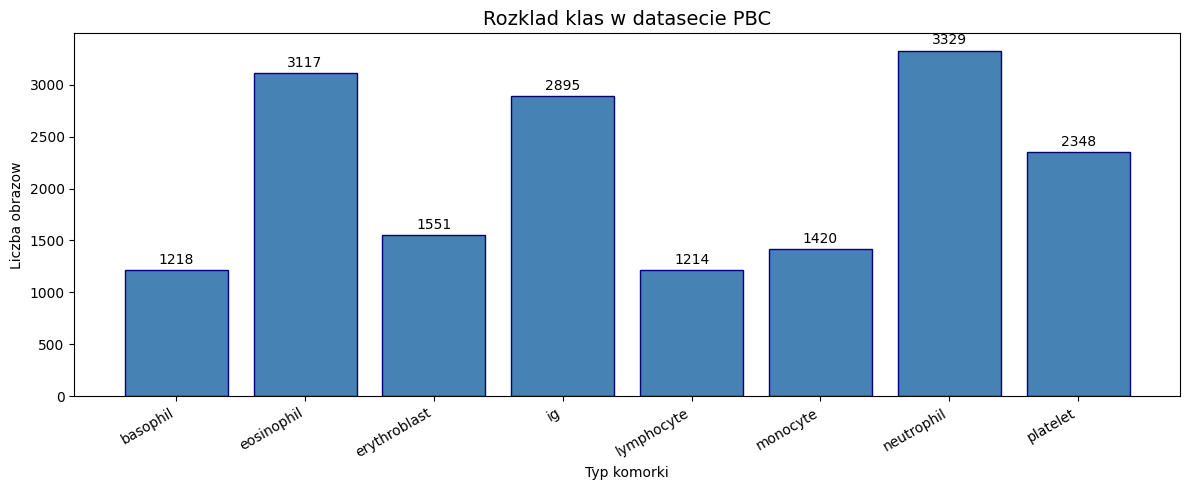

In [6]:
# Histogram rozkladu klas
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='navy')
ax.set_title('Rozklad klas w datasecie PBC', fontsize=14)
ax.set_xlabel('Typ komorki')
ax.set_ylabel('Liczba obrazow')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

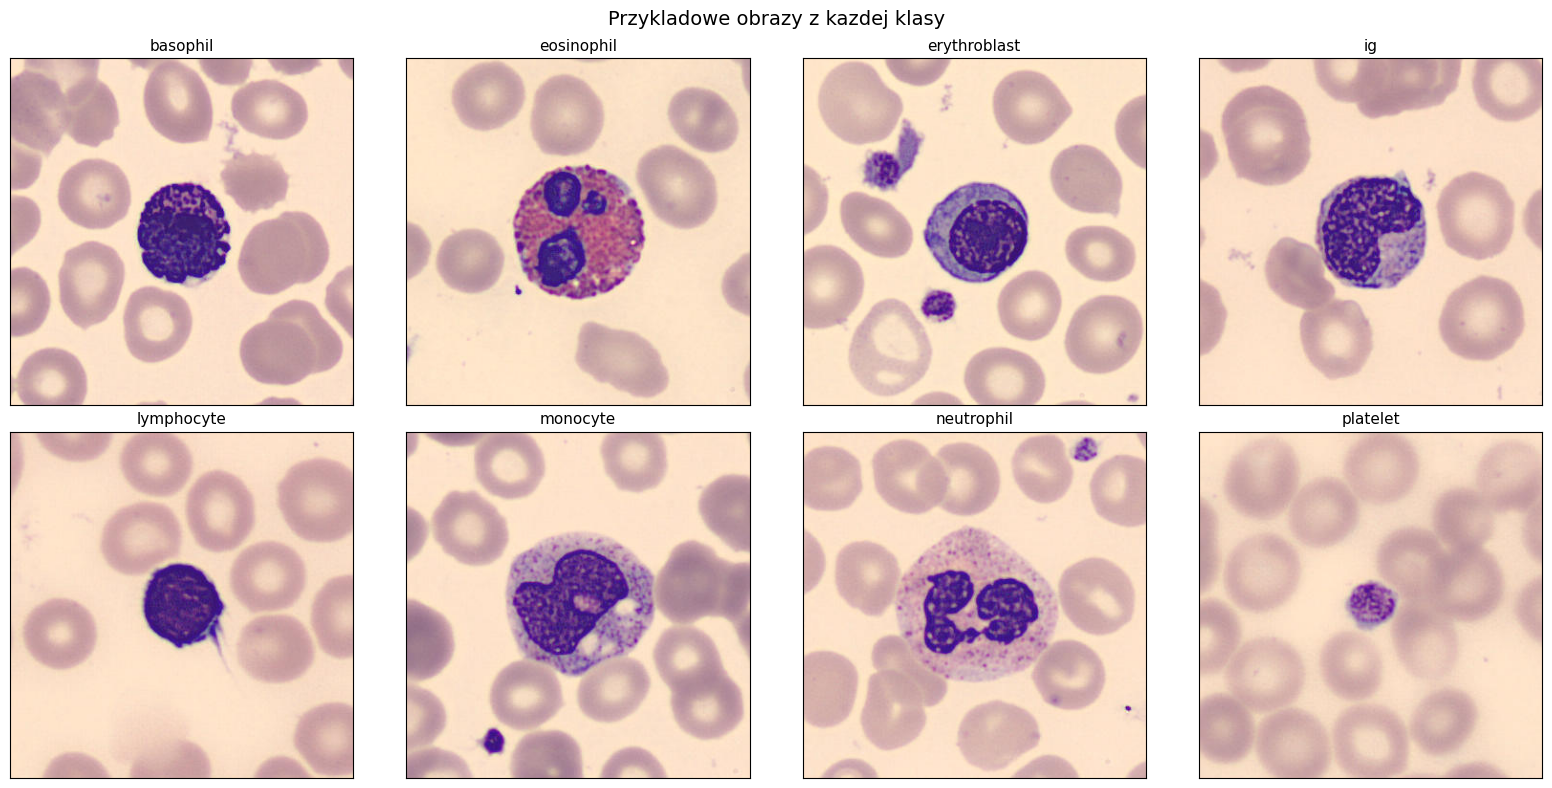

In [7]:
# Przykladowe obrazy z kazdej klasy
from PIL import Image

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))

for cls, ax in zip(class_counts.keys(), axes.flatten()):
    cls_path = os.path.join(CLASSES_DIR, cls)
    img_file = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.png'))][0]
    img = Image.open(os.path.join(cls_path, img_file))
    ax.imshow(img)
    ax.set_title(cls, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Przykladowe obrazy z kazdej klasy', fontsize=14)
plt.tight_layout()
plt.show()




## Sekcja 3: Normalizacja danych

In [9]:
from PIL import Image
import os

# Dla pierwszego obrazku:
first_class = os.listdir(CLASSES_DIR)[0]
first_img_name = os.listdir(os.path.join(CLASSES_DIR, first_class))[0]
first_img_path = os.path.join(CLASSES_DIR, first_class, first_img_name)

img = Image.open(first_img_path)
print(f"Rozmiar: {img.size}")  # (szerokość, wysokość)
print(f"Tryb: {img.mode}")

Rozmiar: (360, 363)
Tryb: RGB


In [10]:
# mean i std z datasetu treningowego

#oryginał: 360x363 px  →  Resize  →  128x128 px
IMG_SIZE = 128

transform_basic = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

temp_dataset = ImageFolder(root=CLASSES_DIR, transform=transform_basic)
temp_loader = DataLoader(temp_dataset, batch_size=64, shuffle=False)

mean = torch.zeros(3)
std = torch.zeros(3)
for images, _ in temp_loader:
    mean += images.mean([0, 2, 3])
    std += images.std([0, 2, 3])

mean /= len(temp_loader)
std /= len(temp_loader)
print(f"mean: {mean}")
print(f"std:  {std}")

mean: tensor([0.8740, 0.7488, 0.7216])
std:  tensor([0.1532, 0.1792, 0.0773])


In [11]:
BATCH_SIZE  = 64 #na razie tak
NUM_CLASSES = 8

# Transformacje dla zbioru treningowego z modyfikacjami! + Normalizacja!
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.8740, 0.7488, 0.7216],
                         std=[0.1532, 0.1792, 0.0773])
])

# Transformacje dla walidacji i test + Normalizacja!
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.8740, 0.7488, 0.7216],
                         std=[0.1532, 0.1792, 0.0773])
])


In [12]:
# Wczytanie datasetu
full_dataset = datasets.ImageFolder(root=CLASSES_DIR, transform=train_transform)

print(f"Lacznie: {len(full_dataset)} obrazow")
print(f"Klasy: {full_dataset.classes}")
print(f"Ksztalt obrazu: {full_dataset[0][0].shape}")

# Podział na train, val i test
train_set, val_set, test_set = random_split(full_dataset, [0.7, 0.15, 0.15])

val_set.dataset.transform  = val_test_transform
test_set.dataset.transform = val_test_transform

print(f"Train: {len(train_set)}")
print(f"Val:   {len(val_set)}")
print(f"Test:  {len(test_set)}")

Lacznie: 17092 obrazow
Klasy: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
Ksztalt obrazu: torch.Size([3, 128, 128])
Train: 11965
Val:   2564
Test:  2563


In [13]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Liczba batchy: Train={len(train_loader)}, Val={len(val_loader)}, Test={len(test_loader)}")

Liczba batchy: Train=187, Val=41, Test=41


## Sekcja 4: Accuracy + petla treningowa

In [14]:
# Jaka jest dokładność modelu na zbiorze
def get_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)       # gdzie najwieksza wartosc
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# Pętla zwracająca historie loss i accuracy
def train(model, train_loader, val_loader, num_epochs=20, learn_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learn_rate)

    losses, train_acc, val_acc = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # Forward
            out = model(imgs)
            loss = criterion(out, labels)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Sredni loss z epoki
        epoch_loss = running_loss / len(train_loader)
        losses.append(epoch_loss)

        # Accuracy raz na epoke
        t_acc = get_accuracy(model, train_loader)
        v_acc = get_accuracy(model, val_loader)
        train_acc.append(t_acc)
        val_acc.append(v_acc)

        print(f"Epoka [{epoch+1:02d}/{num_epochs}]  Loss: {epoch_loss:.4f}  "
              f"Train Acc: {t_acc*100:.1f}%  Val Acc: {v_acc*100:.1f}%")

    return losses, train_acc, val_acc

In [16]:
def plot_history(losses, train_acc, val_acc, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(losses, color='tomato')
    ax1.set_title(f'{title} - Loss (train)')
    ax1.set_xlabel('Epoka')
    ax1.set_ylabel('CrossEntropyLoss')

    ax2.plot(train_acc, label='Train', color='steelblue')
    ax2.plot(val_acc,   label='Val',   color='orange')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoka')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

## Sekcja 5: Augmentacja danych (wyrównanie do 3350 obrazów przez obroty)

In [23]:
import random

TARGET = 3350

# Transform z rotacją
rotation_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(25),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.8740, 0.7488, 0.7216],
                         std=[0.1532, 0.1792, 0.0773])
])

base_dataset = datasets.ImageFolder(root=CLASSES_DIR, transform=train_transform)
rot_dataset  = datasets.ImageFolder(root=CLASSES_DIR, transform=rotation_transform)

# Indeksy per klasa
from collections import defaultdict
indices_per_class = defaultdict(list)
for idx, (_, label) in enumerate(base_dataset.samples):
    indices_per_class[label].append(idx)

print("Przed augmentacją:")
for label, idxs in indices_per_class.items():
    print(f"  {base_dataset.classes[label]:20s}: {len(idxs)}")

Przed augmentacją:
  basophil            : 1218
  eosinophil          : 3117
  erythroblast        : 1551
  ig                  : 2895
  lymphocyte          : 1214
  monocyte            : 1420
  neutrophil          : 3329
  platelet            : 2348


In [24]:
# Dogenerowanie do 3350 (obrócone kopie)
from torch.utils.data import ConcatDataset, Subset

random.seed(1)
datasets_list = [base_dataset]

for label, idxs in indices_per_class.items():
    n = len(idxs)
    if n < TARGET:
        needed  = TARGET - n
        extra   = random.choices(idxs, k=needed)  # losuj z powtorzeniami
        datasets_list.append(Subset(rot_dataset, extra))

train_set = ConcatDataset(datasets_list)
print(f"\nPo augmentacji: {len(train_set)} obrazów")
print(f"Oczekiwane:     {TARGET * NUM_CLASSES} = {TARGET} x {NUM_CLASSES} klas")


Po augmentacji: 26800 obrazów
Oczekiwane:     26800 = 3350 x 8 klas


In [25]:
# Val i test — bez augmentacji
full_eval = datasets.ImageFolder(root=CLASSES_DIR, transform=val_test_transform)

train_size = int(0.70 * len(full_eval))
val_size   = int(0.15 * len(full_eval))
test_size  = len(full_eval) - train_size - val_size

train_eval, val_set, test_set = random_split(full_eval, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")
print(f"Train batche: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Train: 26800, Val: 2563, Test: 2565
Train batche: 419, Val: 41, Test: 41


## Sekcja 6: Model 1 - Mała sieć (SmallNet)

In [27]:
class SmallNet(nn.Module):
    def __init__(self, num_classes=8):
        super(SmallNet, self).__init__()

        # Blok 1: 128x128 -> 64x64
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Blok 2: 64x64 -> 32x32
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc = nn.Linear(32 * 32 * 32, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        return out


model_small = SmallNet(num_classes=NUM_CLASSES).to(device)
params = sum(p.numel() for p in model_small.parameters() if p.requires_grad)
print(f"1 model - SmallNet — liczba parametrów: {params:,}")

1 model - SmallNet — liczba parametrów: 276,296


In [28]:
# Trening SmallNet
losses_small, train_acc_small, val_acc_small = train(
    model_small, train_loader, val_loader, num_epochs=20, learn_rate=0.001
)

Epoka [01/20]  Loss: 0.9996  Train Acc: 79.5%  Val Acc: 79.4%
Epoka [02/20]  Loss: 0.4697  Train Acc: 89.6%  Val Acc: 87.6%
Epoka [03/20]  Loss: 0.3284  Train Acc: 90.8%  Val Acc: 90.3%
Epoka [04/20]  Loss: 0.2896  Train Acc: 88.0%  Val Acc: 90.6%
Epoka [05/20]  Loss: 0.2460  Train Acc: 91.6%  Val Acc: 91.2%
Epoka [06/20]  Loss: 0.2237  Train Acc: 93.6%  Val Acc: 94.6%
Epoka [07/20]  Loss: 0.1976  Train Acc: 94.1%  Val Acc: 95.2%
Epoka [08/20]  Loss: 0.1850  Train Acc: 94.8%  Val Acc: 95.3%
Epoka [09/20]  Loss: 0.1753  Train Acc: 94.9%  Val Acc: 95.3%
Epoka [10/20]  Loss: 0.1637  Train Acc: 95.8%  Val Acc: 96.0%
Epoka [11/20]  Loss: 0.1552  Train Acc: 95.5%  Val Acc: 95.6%
Epoka [12/20]  Loss: 0.1468  Train Acc: 94.5%  Val Acc: 93.3%
Epoka [13/20]  Loss: 0.1408  Train Acc: 94.6%  Val Acc: 95.9%
Epoka [14/20]  Loss: 0.1356  Train Acc: 96.0%  Val Acc: 96.1%
Epoka [15/20]  Loss: 0.1237  Train Acc: 95.5%  Val Acc: 96.8%
Epoka [16/20]  Loss: 0.1258  Train Acc: 96.2%  Val Acc: 95.7%
Epoka [1

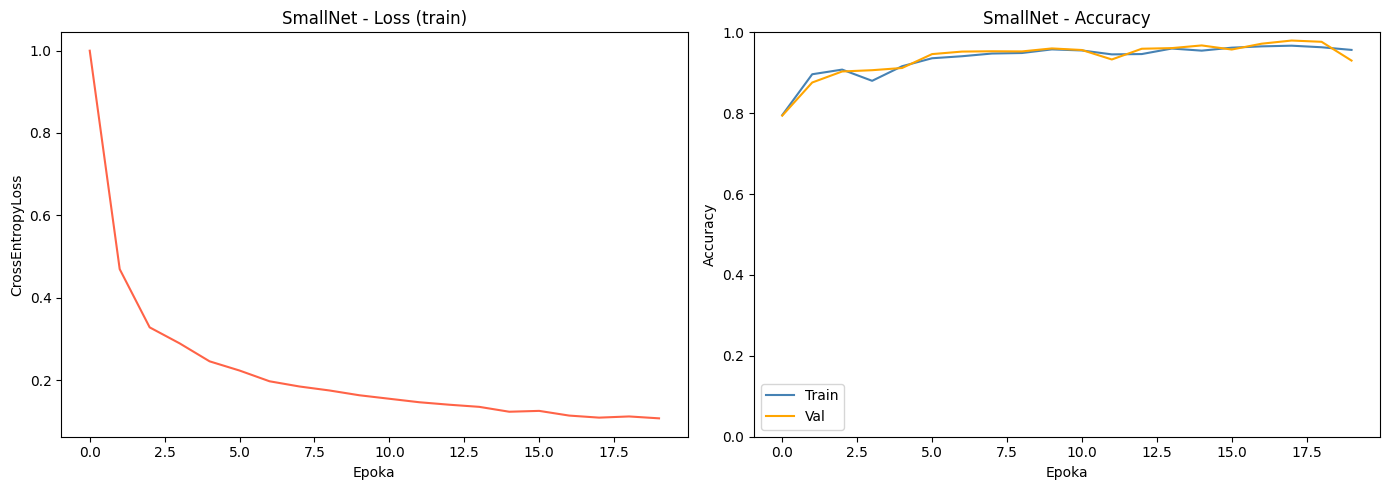

In [29]:
plot_history(losses_small, train_acc_small, val_acc_small, title='SmallNet')

In [30]:
test_acc_small = get_accuracy(model_small, test_loader)
print(f"SmallNet — Accuracy na zbiorze testowym: {test_acc_small*100:.2f}%")

SmallNet — Accuracy na zbiorze testowym: 92.67%


## Sekcja 7: Model 2 - Większa sieć (DeepNet)

In [31]:
class DeepNet(nn.Module):
    def __init__(self, num_classes=8):
        super(DeepNet, self).__init__()

        # Blok 1: 128x128 -> 64x64
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Blok 2: 64x64 -> 32x32
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Blok 3: 32x32 -> 16x16
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = out.reshape(out.size(0), -1)
        out = self.dropout(out)
        out = F.relu(self.fc1(out))
        out = self.fc2(out)
        return out


model_deep = DeepNet(num_classes=NUM_CLASSES).to(device)
params = sum(p.numel() for p in model_deep.parameters() if p.requires_grad)
print(f"2 model - DeepNet — liczba parametrów: {params:,}")

2 model - DeepNet — liczba parametrów: 8,518,920


In [32]:
# Trening DeepNet
losses_deep, train_acc_deep, val_acc_deep = train(
    model_deep, train_loader, val_loader, num_epochs=20, learn_rate=0.001
)

Epoka [01/20]  Loss: 1.1078  Train Acc: 79.8%  Val Acc: 73.7%
Epoka [02/20]  Loss: 0.4074  Train Acc: 88.5%  Val Acc: 91.4%
Epoka [03/20]  Loss: 0.2846  Train Acc: 90.5%  Val Acc: 90.6%
Epoka [04/20]  Loss: 0.2473  Train Acc: 93.6%  Val Acc: 95.2%
Epoka [05/20]  Loss: 0.2142  Train Acc: 89.8%  Val Acc: 89.8%
Epoka [06/20]  Loss: 0.1926  Train Acc: 94.3%  Val Acc: 93.1%
Epoka [07/20]  Loss: 0.1795  Train Acc: 94.3%  Val Acc: 95.9%
Epoka [08/20]  Loss: 0.1662  Train Acc: 94.2%  Val Acc: 94.7%
Epoka [09/20]  Loss: 0.1580  Train Acc: 93.3%  Val Acc: 94.6%
Epoka [10/20]  Loss: 0.1440  Train Acc: 96.3%  Val Acc: 94.6%
Epoka [11/20]  Loss: 0.1334  Train Acc: 95.0%  Val Acc: 96.1%
Epoka [12/20]  Loss: 0.1318  Train Acc: 96.4%  Val Acc: 96.2%
Epoka [13/20]  Loss: 0.1194  Train Acc: 96.5%  Val Acc: 96.3%
Epoka [14/20]  Loss: 0.1189  Train Acc: 97.0%  Val Acc: 97.5%
Epoka [15/20]  Loss: 0.1096  Train Acc: 95.5%  Val Acc: 95.1%
Epoka [16/20]  Loss: 0.1040  Train Acc: 93.0%  Val Acc: 93.2%
Epoka [1

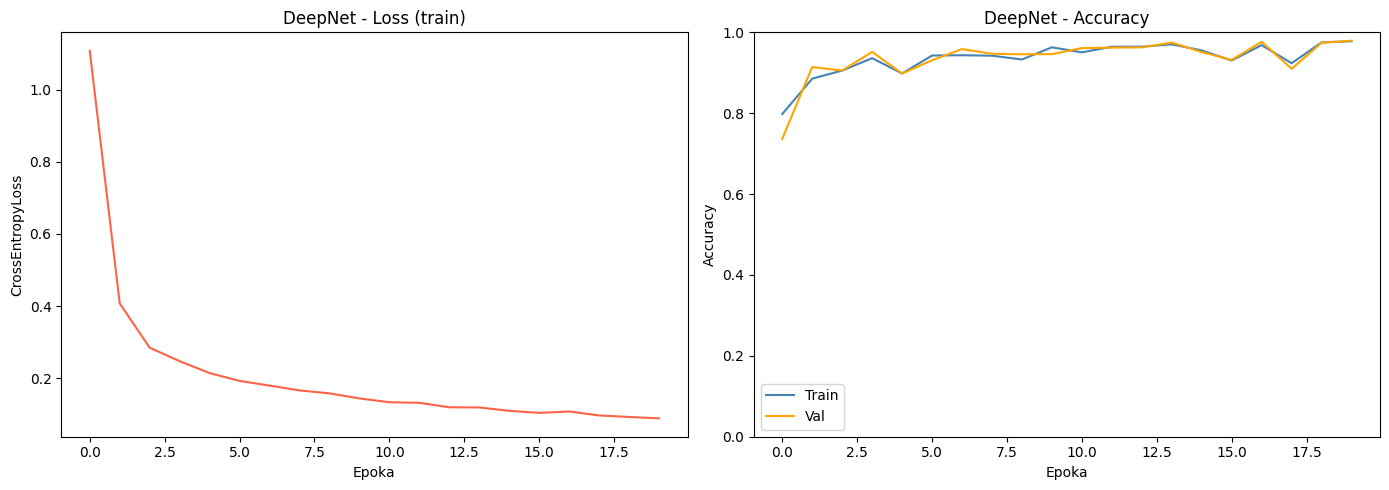

In [33]:
plot_history(losses_deep, train_acc_deep, val_acc_deep, title='DeepNet')

In [34]:
test_acc_deep = get_accuracy(model_deep, test_loader)
print(f"DeepNet — Accuracy na zbiorze testowym: {test_acc_deep*100:.2f}%")

DeepNet — Accuracy na zbiorze testowym: 97.97%


SmallNet ma 2 bloki i mniej filtrów, DeepNet ma 3 bloki z Dropoutem i dwie warstwy FC

## Sekcja 8: Porównanie modeli

In [35]:
print(f"{'Model':<20} {'Parametry':>10} {'Test Acc':>10}")
print(f"{'SmallNet':<20} {sum(p.numel() for p in model_small.parameters()):>10,} {test_acc_small*100:>9.2f}%")
print(f"{'DeepNet':<20} {sum(p.numel() for p in model_deep.parameters()):>10,} {test_acc_deep*100:>9.2f}%")

Model                 Parametry   Test Acc
SmallNet                276,296     92.67%
DeepNet               8,518,920     97.97%


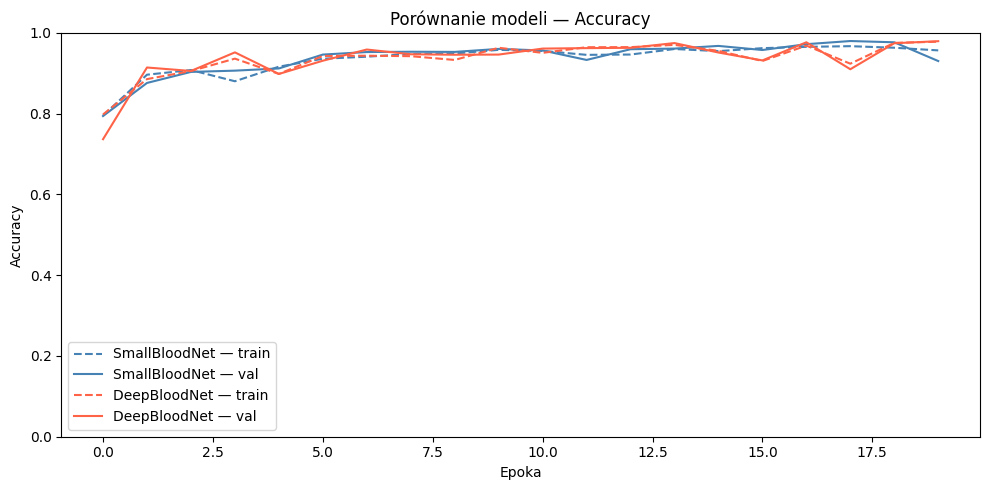

In [36]:
# Accuracy obu modeli
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(train_acc_small, label='SmallBloodNet — train', color='steelblue',  linestyle='--')
ax.plot(val_acc_small,   label='SmallBloodNet — val',   color='steelblue')
ax.plot(train_acc_deep,  label='DeepBloodNet — train',  color='tomato',     linestyle='--')
ax.plot(val_acc_deep,    label='DeepBloodNet — val',    color='tomato')

ax.set_title('Porównanie modeli — Accuracy')
ax.set_xlabel('Epoka')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Sekcja 9: Confusion Matrix
Na ile model się myli z rozpoznawaniem prawdziwych typów komórek krwi (bazofile, eozynofile)

In [37]:
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)

    # Normalizacja: kazdy wiersz sumuje sie do 1 (procent poprawnych dla kazdej klasy)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Predykcja')
    ax.set_ylabel('Prawdziwa klasa')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

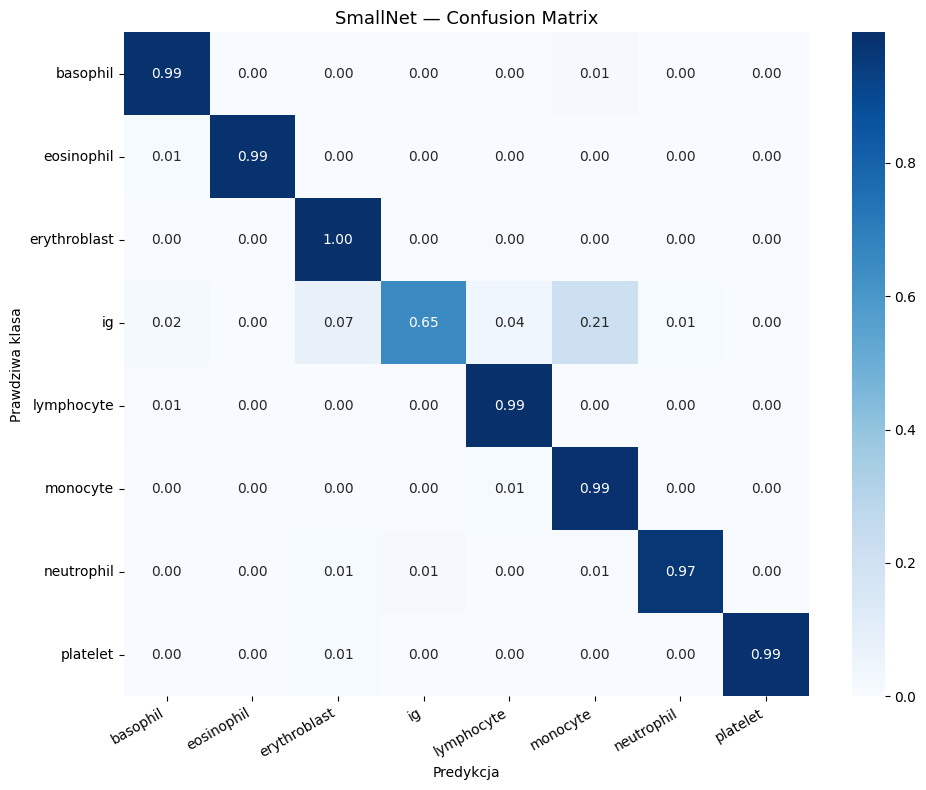

In [38]:
class_labels = base_dataset.classes

y_true_small, y_pred_small = get_predictions(model_small, test_loader)
plot_confusion_matrix(y_true_small, y_pred_small, class_labels, title='SmallNet — Confusion Matrix')

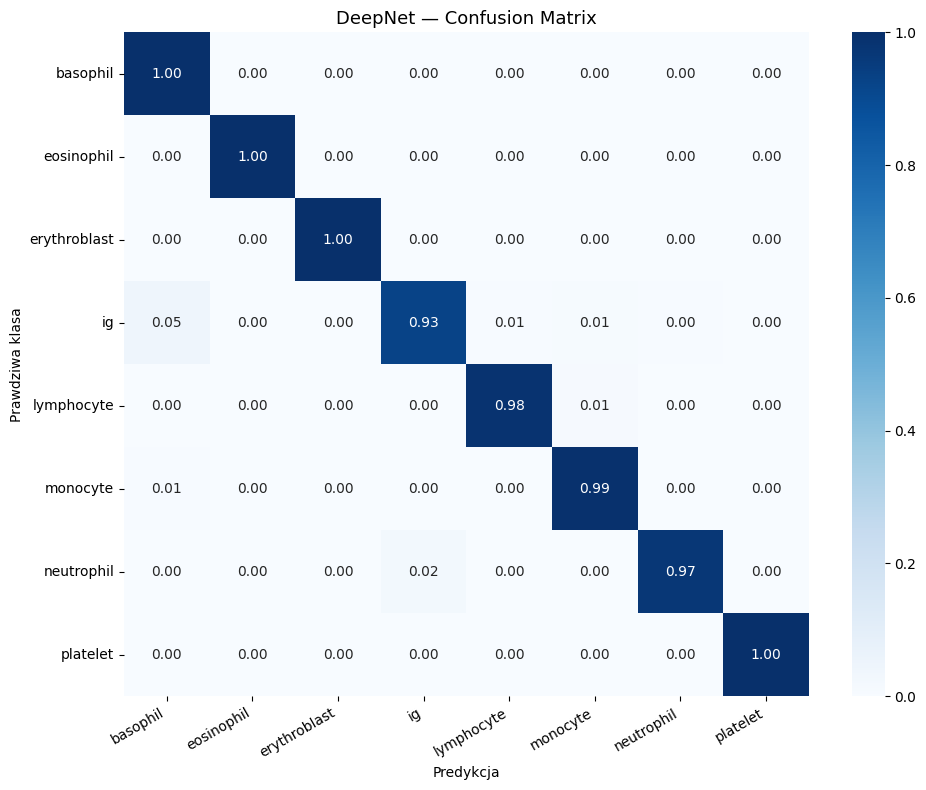

In [39]:
y_true_deep, y_pred_deep = get_predictions(model_deep, test_loader)
plot_confusion_matrix(y_true_deep, y_pred_deep, class_labels, title='DeepNet — Confusion Matrix')

In [41]:
# Classification report dla każdej klasy
print(" --> SmallNet <--")
print(classification_report(y_true_small, y_pred_small, target_names=class_labels))

print("--> DeepNet <--")
print(classification_report(y_true_deep, y_pred_deep, target_names=class_labels))

 --> SmallNet <--
              precision    recall  f1-score   support

    basophil       0.92      0.99      0.95       164
  eosinophil       1.00      0.99      0.99       468
erythroblast       0.85      1.00      0.91       231
          ig       0.98      0.65      0.78       441
  lymphocyte       0.91      0.99      0.95       200
    monocyte       0.67      0.99      0.80       199
  neutrophil       0.99      0.97      0.98       500
    platelet       1.00      0.99      1.00       362

    accuracy                           0.93      2565
   macro avg       0.91      0.94      0.92      2565
weighted avg       0.94      0.93      0.93      2565

--> DeepNet <--
              precision    recall  f1-score   support

    basophil       0.88      1.00      0.94       164
  eosinophil       1.00      1.00      1.00       468
erythroblast       0.99      1.00      1.00       231
          ig       0.97      0.93      0.95       441
  lymphocyte       0.98      0.98      0.98 

# Pobieranie danych z Kaggle https://www.kaggle.com/datasets/masoudnickparvar/white-blood-cells-dataset (Testowanie modelu)

In [42]:
DATA_DIR_2 = kagglehub.dataset_download("masoudnickparvar/white-blood-cells-dataset")

print(f"Dataset jest pod: {DATA_DIR_2}")

100%|██████████| 499M/499M [00:07<00:00, 70.5MB/s]

Extracting files...


Dataset jest pod: /root/.cache/kagglehub/datasets/masoudnickparvar/white-blood-cells-dataset/versions/1


In [43]:
COMMON_CLASSES = ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']

dataset2 = ImageFolder(root=f"{DATA_DIR_2}/Test-A", transform=val_test_transform)
print(f"Klasy drugiego datasetu: {dataset2.classes}")

Klasy drugiego datasetu: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


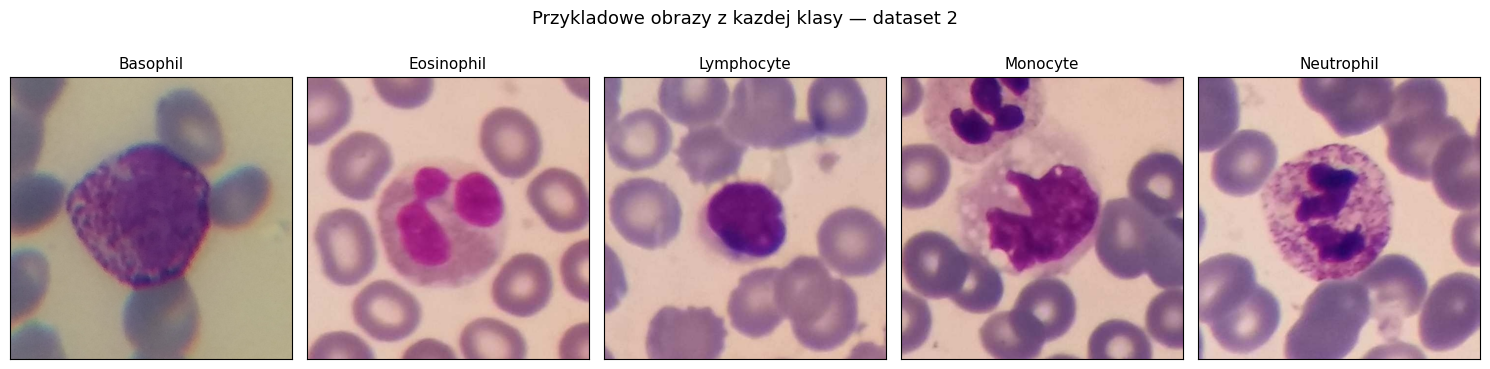

In [44]:
# Przykladowe obrazy z kazdej klasy — drugi dataset
CLASSES_DIR_2 = f"{DATA_DIR_2}/Test-A"

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(15, 4))

for cls, ax in zip(sorted(os.listdir(CLASSES_DIR_2)), axes.flatten()):
    cls_path = os.path.join(CLASSES_DIR_2, cls)
    img_file = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.png'))][0]
    img = Image.open(os.path.join(cls_path, img_file))
    ax.imshow(img)
    ax.set_title(cls, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Przykladowe obrazy z kazdej klasy — dataset 2', fontsize=13)
plt.tight_layout()
plt.show()

In [45]:
# Indeksy klas wspólnych w pierwszym datasecie
# base_dataset.classes = ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
classes_lower = [c.lower() for c in COMMON_CLASSES]
common_idx_ds1 = [base_dataset.classes.index(c) for c in classes_lower]
common_idx_ds2 = [dataset2.classes.index(c) for c in COMMON_CLASSES]

print(f"Indeksy w datasecie 1: {common_idx_ds1}")
print(f"Indeksy w datasecie 2: {common_idx_ds2}")

Indeksy w datasecie 1: [0, 1, 4, 5, 6]
Indeksy w datasecie 2: [0, 1, 2, 3, 4]


In [46]:
# Filtruj drugi dataset — zostaw tylko wspólne klasy
indices_common = [i for i, (_, label) in enumerate(dataset2.samples)
                  if dataset2.classes[label] in COMMON_CLASSES]

dataset2_filtered = Subset(dataset2, indices_common)
loader2 = DataLoader(dataset2_filtered, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=2, pin_memory=True)

print(f"Obrazów po filtrowaniu: {len(dataset2_filtered)}")

Obrazów po filtrowaniu: 4339


In [47]:
# Funkcja accuracy tylko na wspólnych klasach
def get_accuracy_common(model, loader, idx_ds2_to_ds1):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            # Zamień etykiety ds2 na odpowiadające etykiety ds1
            labels_mapped = torch.tensor(
                [idx_ds2_to_ds1[l.item()] for l in labels]
            ).to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels_mapped).sum().item()
            total += labels.size(0)
    return correct / total

# Słownik mapowania: indeks ds2 -> indeks ds1
idx_map = {ds2: ds1 for ds2, ds1 in zip(common_idx_ds2, common_idx_ds1)}
print(f"Mapowanie klas: {idx_map}")

Mapowanie klas: {0: 0, 1: 1, 2: 4, 3: 5, 4: 6}


In [49]:
acc_small_ds2 = get_accuracy_common(model_small, loader2, idx_map)
acc_deep_ds2  = get_accuracy_common(model_deep,  loader2, idx_map)

print(f"{'Model':<20} {'Test Acc (dataset 2)':>15}")
print(f"{'SmallNet':<20} {acc_small_ds2*100:>14.2f}%")
print(f"{'DeepNet':<20} {acc_deep_ds2*100:>14.2f}%")

Model                Test Acc (dataset 2)
SmallNet                      28.62%
DeepNet                       21.64%


/tmp/ipykernel_24002/631332836.py:18: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


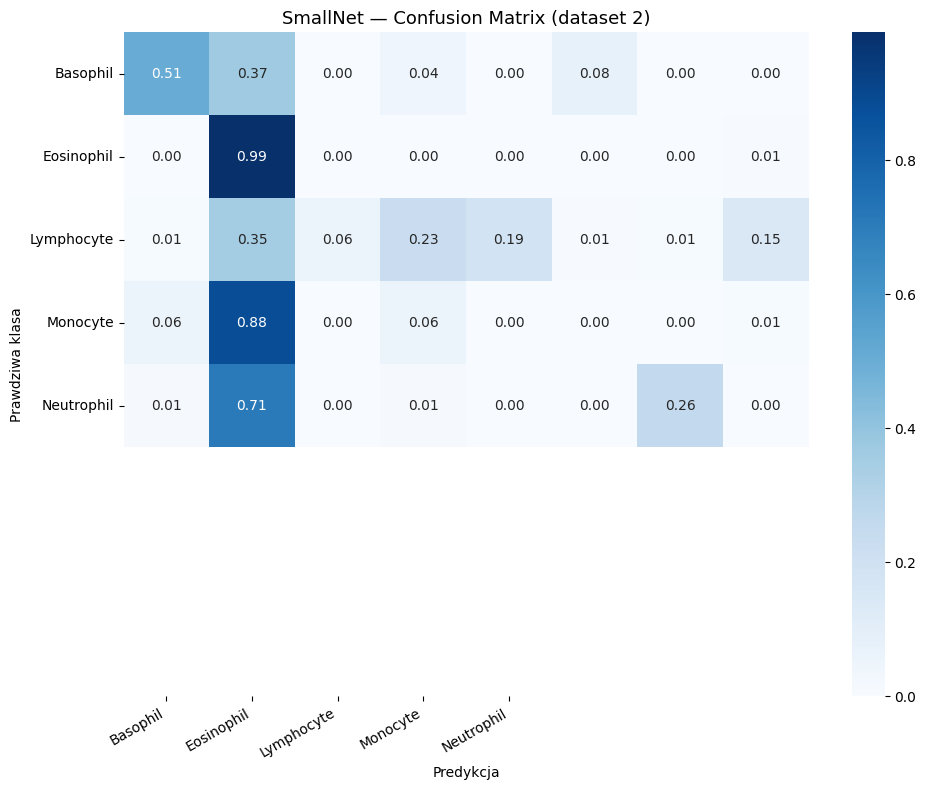

/tmp/ipykernel_24002/631332836.py:18: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


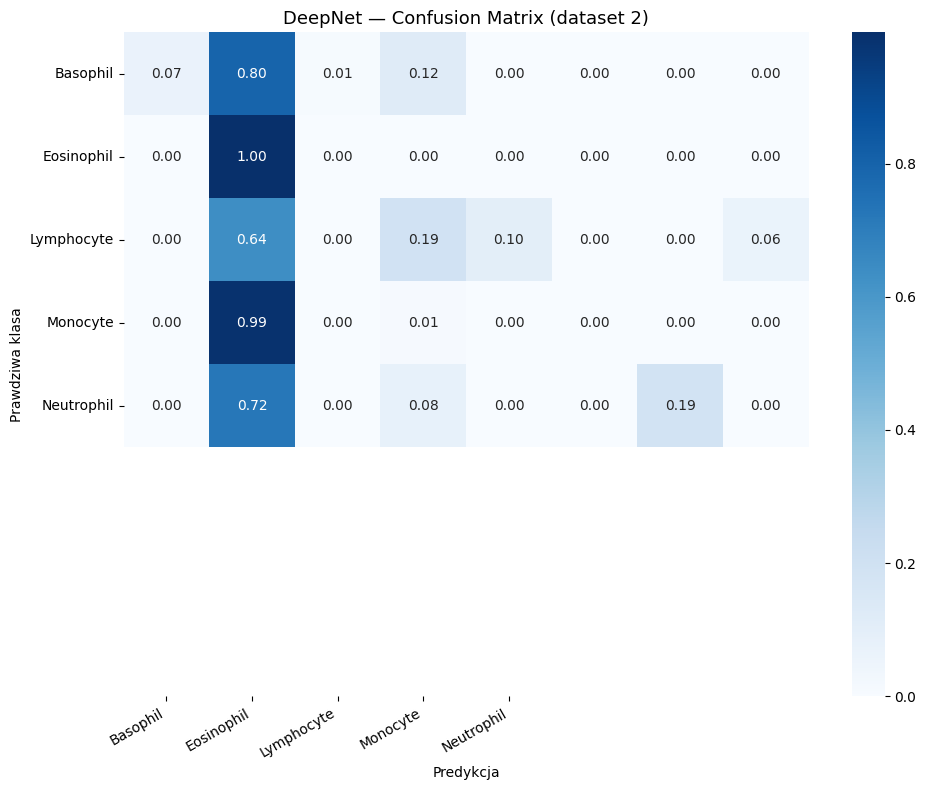

In [50]:
# Confusion matrix na drugim datasecie
y_true2_small, y_pred2_small = get_predictions(model_small, loader2)
y_true2_deep,  y_pred2_deep  = get_predictions(model_deep,  loader2)

# Zamień etykiety na nazwy klas
plot_confusion_matrix(y_true2_small, y_pred2_small, dataset2.classes,
                      title='SmallNet — Confusion Matrix (dataset 2)')
plot_confusion_matrix(y_true2_deep,  y_pred2_deep,  dataset2.classes,
                      title='DeepNet — Confusion Matrix (dataset 2)')

## Sekcja 11: Zapisuje w google drive

In [52]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/Project_ML'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model_small.state_dict(), f'{SAVE_DIR}/small_net.pth')
torch.save(model_deep.state_dict(),  f'{SAVE_DIR}/deep_net.pth')

print(f"Modele zapisane w: {SAVE_DIR}")

Mounted at /content/drive
Modele zapisane w: /content/drive/MyDrive/Project_ML


Wczytanie przez:

model_small = SmallNet(num_classes=NUM_CLASSES).to(device)

model_small.load_state_dict(torch.load(f'{SAVE_DIR}/small_net.pth'))

## WYNIKI

Wyniki testu (acc) dla drugiego datasetu - złe.
Przyczyny:
- inne wybarwienie - pierwszy dataset (PBC) i drugi (white-blood-cells) były barwione innymi metodami w różnych laboratoriach. Sieć nauczyła się kolorów z pierwszego datasetu i nie rozpoznaje tych samych komórek w innym kolorze.
- różne mikroskopy - inne powiększenie, inne oświetlenie, inna jakość obrazu.

Trzeba jakoś zgenealizować sieci neuronowe.

Model wytrenowany na jednym datasecie słabo generalizuje na inny, przy czym klase są takie same - w medycynie to już problem.